# 线性回归完整实现

流程：
- 生成一份可控的线性数据集
- 从零实现模型、损失函数、优化算法
- 训练并观察损失下降

In [1]:
import random
import torch
from torch import Tensor
import matplotlib.pyplot as plt

## 1. 生成数据

设定参数 w 和 b，然后构造输入 X，再加上噪声得到标签 y。

- torch.normal(mean, std, size) 生成正态分布数据
- matmul为矩阵乘法matrix multiply
- 加入噪声让数据更贴近真实场景

In [ ]:
def synthetic_data(w, b, num_examples):  #@save
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape) # 添加噪声
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0],'\nlabel:', labels[0])

(torch.Size([1000, 2]), torch.Size([1000, 1]))

可视化其中一个特征与标签的关系，应该接近一条直线。

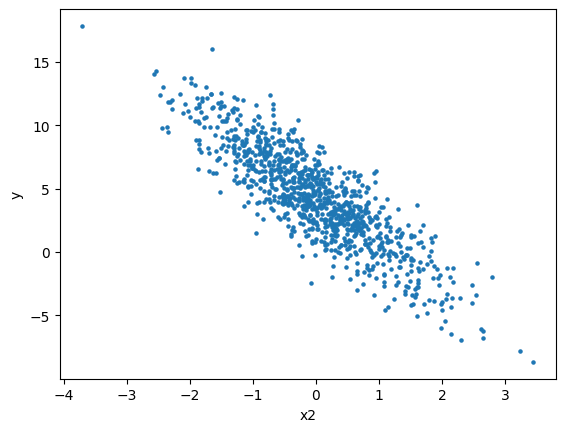

In [ ]:
plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), s=5)
plt.xlplt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), s=5)
plt.xlabel('x2')
plt.ylabel('y')
plt.ylabel('y')
plt.show()

## 2. 小批量数据迭代器

训练时一般使用小批量随机梯度下降（SGD）。
- 先打乱索引
- 再切分成批量大小 batch_size
- 每次 yield 一小批数据

In [4]:
def data_iter(batch_size: int, features: Tensor, labels: Tensor):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:i + batch_size])
        yield features[batch_indices], labels[batch_indices]

## 3. 初始化模型参数

我们要学习的是参数 w 和 b。
- requires_grad=True 让 PyTorch 记录梯度
- torch.zeros(1) 初始化偏置

In [5]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

## 4. 定义模型、损失和优化

线性回归模型：y_hat = X w + b
平方损失：loss = 1/2 (y_hat - y)^2

sgd 的核心是用梯度更新参数：
theta <- theta - eta * d loss / d theta

In [6]:
def linreg(X: Tensor, w: Tensor, b: Tensor):
    return X @ w + b

def squared_loss(y_hat: Tensor, y: Tensor):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

def sgd(params, lr: float, batch_size: int):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## 5. 训练循环

- 正向计算得到预测值
- 计算损失并反向传播
- 用 sgd 更新参数
- 记录每个 epoch 的平均损失

In [7]:
lr = 0.03
num_epochs = 5
batch_size = 10
losses = []

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        y_hat = linreg(X, w, b)
        l = squared_loss(y_hat, y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = squared_loss(linreg(features, w, b), labels)
        mean_l = float(train_l.mean())
        losses.append(mean_l)
    print(f'epoch {epoch + 1}, loss {mean_l:.6f}')

epoch 1, loss 0.034155
epoch 2, loss 0.000116
epoch 3, loss 0.000049
epoch 4, loss 0.000049
epoch 5, loss 0.000049


绘制损失曲线，确认模型确实在收敛。

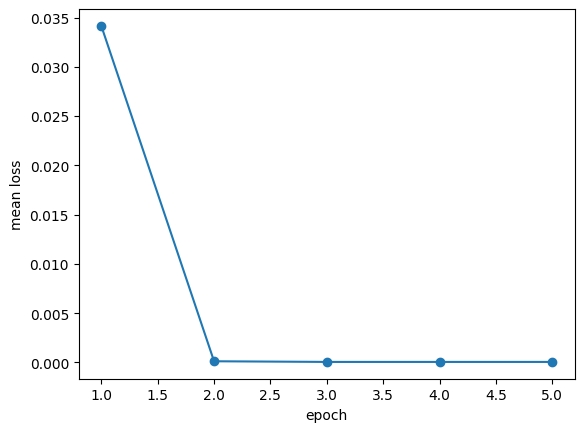

In [8]:
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('epoch')
plt.ylabel('mean loss')
plt.show()

## 6. 对比学到的参数

如果训练正常，学到的 w 和 b 应接近真实值。

In [9]:
print('estimated w:', w.reshape(-1).tolist())
print('estimated b:', float(b))
print('true w:', true_w.tolist())
print('true b:', true_b)

estimated w: [1.9997745752334595, -3.399982452392578]
estimated b: 4.199831962585449
true w: [2.0, -3.4000000953674316]
true b: 4.2


## 讲解要点（更口语的总结）

1. 线性回归的本质：用一条直线（高维是超平面）去拟合数据。参数 w 控制方向，b 控制偏移。
2. 为什么要损失函数：损失函数衡量预测和真实的差距，训练就是让损失最小化。
3. 梯度下降的作用：告诉我们沿着最陡的下降方向更新参数，每次走一小步。
4. 小批量的意义：比全量更快、更稳定，比单样本噪声更小。
5. 从零实现的好处：看清模型、损失、优化三者如何配合，后面用高级 API 才不会是黑盒。